
# Project 1 - Twitter US Airline Sentiment - Gogolin


## Data Set

- tweet_id                                                           
- airline_sentiment                                               
- airline_sentiment_confidence                               
- negativereason                                                   
- negativereason_confidence                                    
- airline                                                                    
- airline_sentiment_gold                                              
- name     
- negativereason_gold
- retweet_count
- text
- tweet_coord
- tweet_created
- tweet_location
- user_timezone


## Steps:
- Import the necessary libraries
- Get the data
- Explore the data
- Do feature engineering (create relevant columns based on existing columns)
- Plot the wordcloud based on the relevant column
- Do pre-processing
- Noise removal (Special character, html tags, numbers,
stopword removal)
- Lowercasing
- Stemming / lemmatization
- Text to number: Vectorization
- CountVectorizer
- TfidfVectorizer
- Build Machine Learning Model for Text Classification.
- Optimize the parameter
- Plot the worldcloud based on the most important features
- Check the performance of the model
- Summary

## Objective:

To implement the techniques learned as a part of the course.


## Learning Outcomes:

- Basic understanding of text pre-processing.
- What to do after text pre-processing
- Bag of words
- Tf-idf
- Build the classification model.
- Evaluate the Model

In [4]:
# install and import necessary libraries.

!pip install contractions

import re, string, unicodedata                          # Import Regex, string and unicodedata.
import contractions                                     # Import contractions library.
from bs4 import BeautifulSoup                           # Import BeautifulSoup.

import numpy as np                                      # Import numpy.
import pandas as pd                                     # Import pandas.
import nltk                                             # Import Natural Language Tool-Kit.

nltk.download('stopwords')                              # Download Stopwords.
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords                       # Import stopwords.
from nltk.tokenize import word_tokenize, sent_tokenize  # Import Tokenizer.
from nltk.stem.wordnet import WordNetLemmatizer         # Import Lemmatizer.

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\codyd\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\codyd\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\codyd\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!

[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# spacy install - conda install

# conda install -c conda-forge spacy

!pip install spacy



[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data Summary

In [6]:
# import the reviews into a dataframe - use your directory
import pandas as pd
data = pd.read_csv('Tweets.csv')

In [7]:
data.shape                                               # print shape of data.

(14640, 15)

 14,640 rows of data with 15 columns.

In [8]:
data.head()                                              # Print first 5 rows of data.

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [9]:
# let's check the data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [10]:
# look for missing data - there are no missing values.
data.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

airline_sentiment_gold and negativereason_gold are pretty much empty and not of use and so will be deleted.

In [11]:
# drop airline_sentiment_gold column as it does not add any value to the analysis
data.drop("airline_sentiment_gold", axis=1, inplace=True)
# drop negativereason_gold column as it does not add any value to the analysis
data.drop("negativereason_gold", axis=1, inplace=True)
# drop tweet_id
data.drop(["tweet_id"], axis=1, inplace=True)

In [12]:
# let's check the data types of the columns in the dataset to make sure the drop worked.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   airline_sentiment             14640 non-null  object 
 1   airline_sentiment_confidence  14640 non-null  float64
 2   negativereason                9178 non-null   object 
 3   negativereason_confidence     10522 non-null  float64
 4   airline                       14640 non-null  object 
 5   name                          14640 non-null  object 
 6   retweet_count                 14640 non-null  int64  
 7   text                          14640 non-null  object 
 8   tweet_coord                   1019 non-null   object 
 9   tweet_created                 14640 non-null  object 
 10  tweet_location                9907 non-null   object 
 11  user_timezone                 9820 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 1.3+ MB


In [13]:
# Check for duplicated values
data.duplicated().sum()

39

In [14]:
# Dropping the 39 duplicates
df_duplicates_removed = data.drop_duplicates()
data.drop_duplicates(inplace=True)
print(df_duplicates_removed)

      airline_sentiment  airline_sentiment_confidence          negativereason  \
0               neutral                        1.0000                     NaN   
1              positive                        0.3486                     NaN   
2               neutral                        0.6837                     NaN   
3              negative                        1.0000              Bad Flight   
4              negative                        1.0000              Can't Tell   
...                 ...                           ...                     ...   
14635          positive                        0.3487                     NaN   
14636          negative                        1.0000  Customer Service Issue   
14637           neutral                        1.0000                     NaN   
14638          negative                        1.0000  Customer Service Issue   
14639           neutral                        0.6771                     NaN   

       negativereason_confi

In [15]:
# let's check to make sure the drop worked.
data.shape

(14601, 12)

## EDA

In [16]:
for col in data:
    print(data[col].unique())

['neutral' 'positive' 'negative']
[1.     0.3486 0.6837 ... 0.6384 0.7094 0.3487]
[nan 'Bad Flight' "Can't Tell" 'Late Flight' 'Customer Service Issue'
 'Flight Booking Problems' 'Lost Luggage' 'Flight Attendant Complaints'
 'Cancelled Flight' 'Damaged Luggage' 'longlines']
[   nan 0.     0.7033 ... 0.6234 0.644  0.7255]
['Virgin America' 'United' 'Southwest' 'Delta' 'US Airways' 'American']
['cairdin' 'jnardino' 'yvonnalynn' ... 'KristenReenders' 'itsropes'
 'sanyabun']
[ 0  1  2  3  4  5  7 22  6 18 15 31 11  8  9 28 32 44]
['@VirginAmerica What @dhepburn said.'
 "@VirginAmerica plus you've added commercials to the experience... tacky."
 "@VirginAmerica I didn't today... Must mean I need to take another trip!"
 ... '@AmericanAir Please bring American Airlines to #BlackBerry10'
 "@AmericanAir you have my money, you change my flight, and don't answer your phones! Any other suggestions so I can make my commitment??"
 '@AmericanAir we have 8 ppl so we need 2 know how many seats are on th

In [17]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

C:\Users\codyd\AppData\Local\Temp\ipykernel_19636\310561115.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Pytho

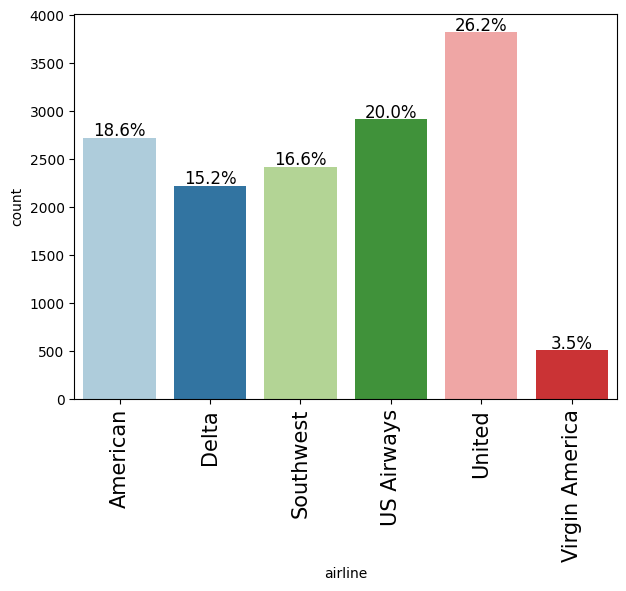

In [18]:
# Tweets among airlines

labeled_barplot(data, "airline", perc=True)

In [19]:
# Look at counts
data["airline"].value_counts()

airline
United            3822
US Airways        2913
American          2720
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

C:\Users\codyd\AppData\Local\Temp\ipykernel_19636\310561115.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Pytho

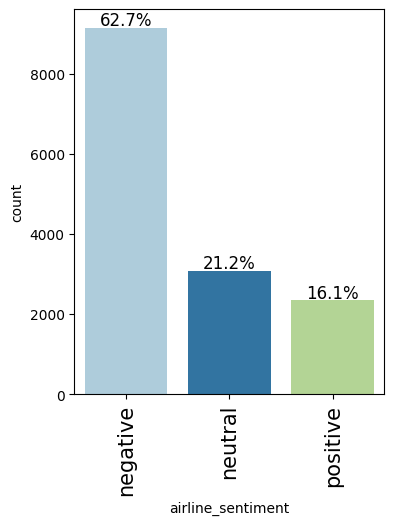

In [20]:
# airline sentiment

labeled_barplot(data, "airline_sentiment", perc=True)

airline sentiment is overwhelmingly negative

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

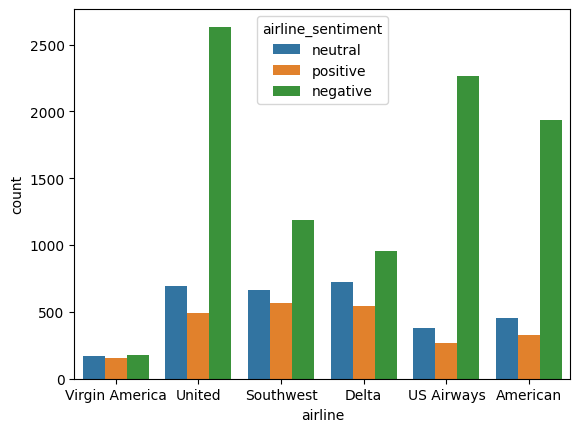

In [21]:
# Check the airline sentiment by airline

sns.countplot(data = data, x='airline',hue='airline_sentiment');

It appears that United, US Airways and American have serious negative sentiment issues.

C:\Users\codyd\AppData\Local\Temp\ipykernel_19636\310561115.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Pytho

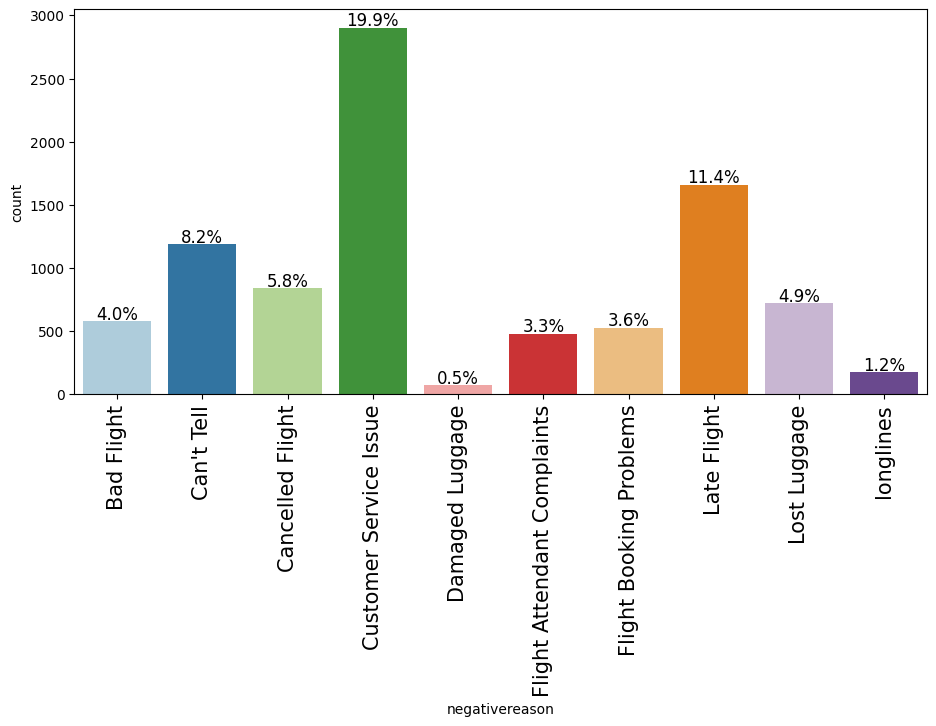

In [22]:
# Negative reasons

labeled_barplot(data, "negativereason", perc=True)

Customer Service and Late Flights are the main negative reasons.

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

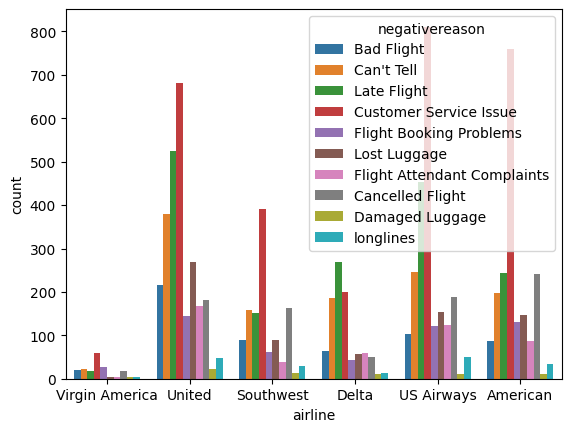

In [23]:
# Check negative reasons by airline

sns.countplot(data = data, x='airline',hue='negativereason');

Customer Service is the main negative reason for United, Southwest, US Airways and American.

In [24]:
# let's view the statistical summary of the numerical columns in the data
data.negativereason.describe().T

count                       9157
unique                        10
top       Customer Service Issue
freq                        2902
Name: negativereason, dtype: object

Confirms customer service is the largest issue.

In [25]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


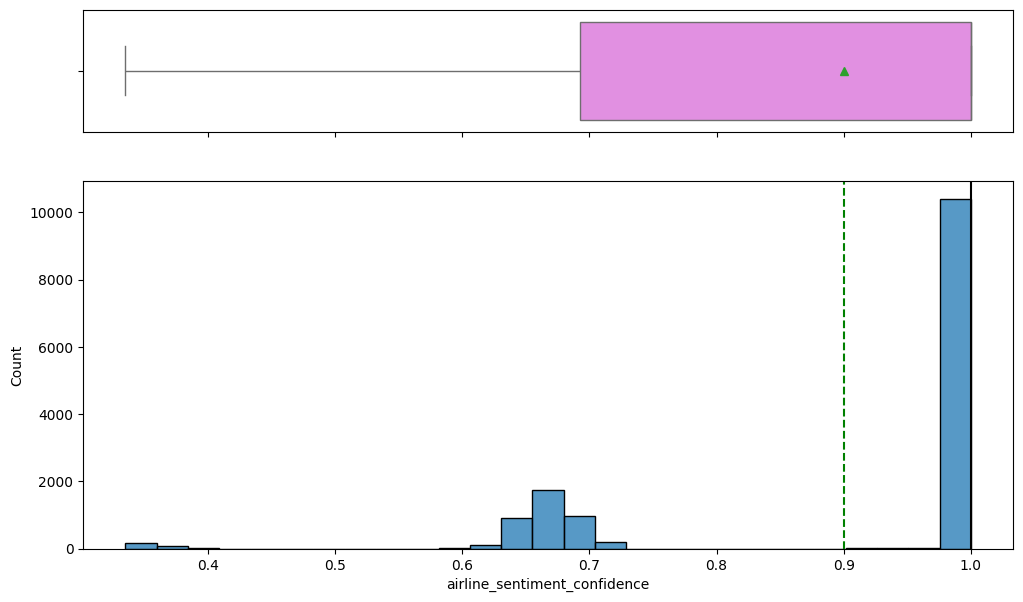

In [26]:
# check airline_sentiment_confidence
histogram_boxplot(data, "airline_sentiment_confidence")

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


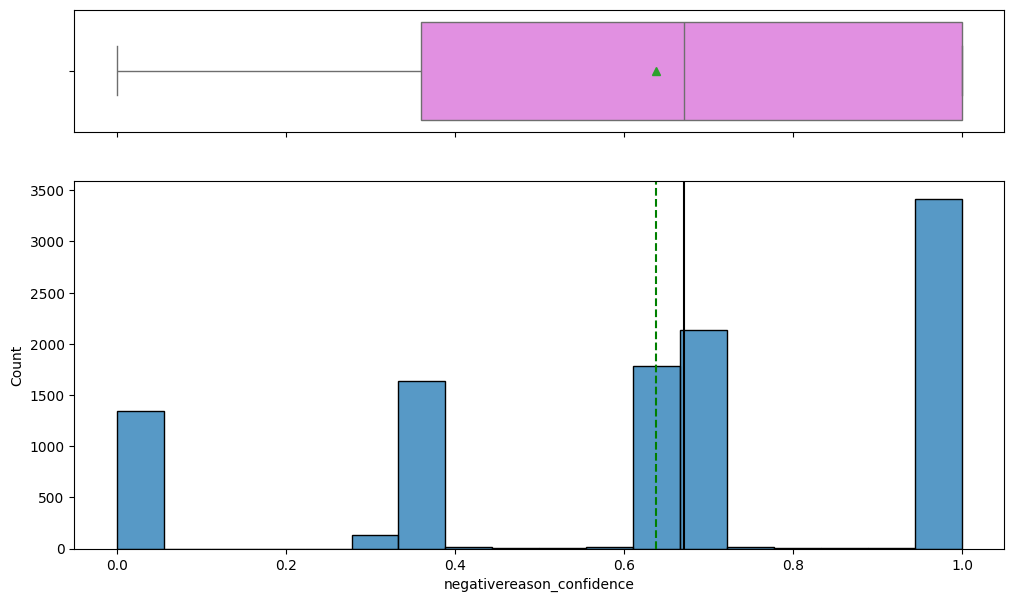

In [27]:
# check negativereason_confidence
histogram_boxplot(data, "negativereason_confidence")

## Bivariate Analysis

In [28]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

ValueError: could not convert string to float: 'neutral'

<Figure size 1500x700 with 0 Axes>

In [ ]:
data.corr()  # It will show correlation matrix

In [ ]:
sns.pairplot(data=data, hue="airline_sentiment")
plt.show()

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(x="retweet_count", y="airline_sentiment_confidence", data=data)
plt.show()

## Statistical Summary

In [ ]:
# let's view the statistical summary of the numerical columns in the data
data.describe().T

In [ ]:
# let's view the statistical summary of the non-numerical columns in the data
data.describe(exclude=np.number).T

## Word Clouds

In [ ]:
from nltk.corpus import stopwords                       # Import stopwords.

In [ ]:
stopwords = stopwords.words('english')

customlist = ['not', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn',
        "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn',
        "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn',
        "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Set custom stop-word's list as not, couldn't etc. words matter in Sentiment, so not removing them from
# original data.

stopwords = list(set(stopwords) - set(customlist))

In [ ]:

data['text'] = data.apply(lambda row: nltk.word_tokenize(row['text']), axis=1) # Tokenization of data

import wordcloud
def show_wordcloud(data, title):
    text = ' '.join(data['text'].astype(str).tolist())                 # Converting text column into list
    stopwords = set(wordcloud.STOPWORDS)                                  # instantiate the stopwords from wordcloud

    fig_wordcloud = wordcloud.WordCloud(stopwords=stopwords,background_color='white',          # Setting the different parameter of stopwords
                    colormap='viridis', width=800, height=600).generate(text)

    plt.figure(figsize=(14,11), frameon=True)
    plt.imshow(fig_wordcloud)
    plt.axis('off')
    plt.title(title, fontsize=30)
    plt.show()

In [ ]:
show_wordcloud(data,'Summary Word_Cloud')

Normally you would perform more pre-processing prior to word cloud but hey, we're learning techniques here...

In [ ]:
show_wordcloud(data[data.airline_sentiment == "positive"], title = "Positive")

Thank you and thanks are main factors in positive sentiment.  

In [ ]:
show_wordcloud(data[data.airline_sentiment == "neutral"], title = "Neutral")

Not a lot of dominant factors in neutral sentiment, although "to" jumps out.  

In [ ]:
show_wordcloud(data[data.airline_sentiment == "negative"], title = "Negative")

Can't, now, flight, hold, cancelled and but are common words that indicate negative sentiment.  

## Understanding of Data Columns

In [ ]:
# let's check the data types of the columns in the dataset
data.info()

In [ ]:
#  deleting all columns except "text" and "airline_sentiment"


data.drop(["airline_sentiment_confidence"], axis=1, inplace=True)
data.drop(["negativereason"], axis=1, inplace=True)
data.drop(["negativereason_confidence"], axis=1, inplace=True)
data.drop(["airline"], axis=1, inplace=True)
data.drop(["name"], axis=1, inplace=True)
data.drop(["retweet_count"], axis=1, inplace=True)
data.drop(["tweet_coord"], axis=1, inplace=True)
data.drop(["tweet_created"], axis=1, inplace=True)
data.drop(["tweet_location"], axis=1, inplace=True)
data.drop(["user_timezone"], axis=1, inplace=True)

In [ ]:
data.shape

In [ ]:
data.head()                                              # Print first 5 rows of data.

In [ ]:
# create copy in case I need to rerun anything
data1 = data.copy()

In [ ]:
# let's check the data types of the columns in the dataset to make sure the drop worked.
data.info()

# Data Pre-Processing

In [ ]:
# use copy
# data = data1.copy()

In [ ]:
# rename text to Text so I don't have to change name in routines
data.rename(columns={'text': 'Text'}, inplace=True)

In [ ]:
data.head()

In [ ]:
# Taking only 50000 entries for demonstration purpose. As full data will take more time to process.
# Only keeping relevant columns from the data, as these are useful for our analysis.

data9 = data.loc[:49999, ['airline_sentiment','Text']]

In [ ]:
# Taking only 2500 entries for demonstration purpose. As full data will take more time to process.
# Only keeping relevant columns from the data, as these are useful for our analysis.
data = data1.sample(n=2500)
data.shape

In [ ]:
data.isnull().sum(axis=0)                             # Check for NULL values.

In [ ]:
data=data.dropna()                                     # Dropping off missing values
data.columns                                           # Print the column of the dataframe

In [ ]:
data.shape                                            #Shape of the data

In [ ]:
pd.set_option('display.max_colwidth', None) # Display full dataframe information (Non-turncated Text column.)

data.head()                                 # Check first 5 rows of data

In [ ]:
data.shape                                # Shape of data

### **Text Pre-processing:**

- Remove html tags.
- Replace contractions in string. (e.g. replace I'm --> I am) and so on.\
- Remove numbers.
- Tokenization
- To remove Stopwords.
- Lemmatized data

We have used the **NLTK library to tokenize words, remove stopwords and lemmatize the remaining words**

In [ ]:
# change object to string

# rename text to Text so I don't have to change name in routines
data.rename(columns={'text': 'Text'}, inplace=True)

data['Text']=data['Text'].astype('string')
data['airline_sentiment']=data['airline_sentiment'].astype('string')

In [ ]:
def strip_html(text):
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()

data['Text'] = data['Text'].apply(lambda x: strip_html(x))

data.head()

In [ ]:
# change object to string

data['Text']=data['Text'].astype('string')
data['airline_sentiment']=data['airline_sentiment'].astype('string')

In [ ]:
def replace_contractions(text):
    """Replace contractions in string of text"""
    return contractions.fix(text)

data['Text'] = data['Text'].apply(lambda x: replace_contractions(x))

data.head()

In [ ]:
# change object to string

data['Text']=data['Text'].astype('string')
data['airline_sentiment']=data['airline_sentiment'].astype('string')

In [ ]:
def remove_numbers(text):
  text = re.sub(r'\d+', '', text)
  return text

data['Text'] = data['Text'].apply(lambda x: remove_numbers(x))

data.head()

In [ ]:
# change object to string

data['Text']=data['Text'].astype('string')
data['airline_sentiment']=data['airline_sentiment'].astype('string')

In [ ]:
data['Text'] = data.apply(lambda row: nltk.word_tokenize(row['Text']), axis=1) # Tokenization of data


In [ ]:
data.head()                                                                    # Look at how tokenized data looks.

In [ ]:
from nltk.corpus import stopwords                       # Import stopwords.

In [ ]:
stopwords = stopwords.words('english')

customlist = ['not', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn',
        "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn',
        "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn',
        "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Set custom stop-word's list as not, couldn't etc. words matter in Sentiment, so not removing them from original data.

stopwords = list(set(stopwords) - set(customlist))

In [ ]:
import nltk
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def remove_non_ascii(words):
    """Remove non-ASCII characters from list of tokenized words"""
    new_words = []
    for word in words:
        new_word = unicodedata.normalize('NFKD', word).encode('ascii', 'ignore').decode('utf-8', 'ignore')
        new_words.append(new_word)
    return new_words

def to_lowercase(words):
    """Convert all characters to lowercase from list of tokenized words"""
    new_words = []
    for word in words:
        new_word = word.lower()
        new_words.append(new_word)
    return new_words

def remove_punctuation(words):
    """Remove punctuation from list of tokenized words"""
    new_words = []
    for word in words:
        new_word = re.sub(r'[^\w\s]', '', word)
        if new_word != '':
            new_words.append(new_word)
    return new_words

def remove_stopwords(words):
    """Remove stop words from list of tokenized words"""
    new_words = []
    for word in words:
        if word not in stopwords:
            new_words.append(word)
    return new_words

def lemmatize_list(words):
    new_words = []
    for word in words:
      new_words.append(lemmatizer.lemmatize(word, pos='v'))
    return new_words

def normalize(words):
    words = remove_non_ascii(words)
    words = to_lowercase(words)
    words = remove_punctuation(words)
    words = remove_stopwords(words)
    words = lemmatize_list(words)
    return ' '.join(words)

data['Text'] = data.apply(lambda row: normalize(row['Text']), axis=1)
data.head()

In [ ]:
# create copy in case I need to rerun anything
data_afterpreprocessing = data.copy()

### **Word Cloud based on Text**

In [ ]:

data['Text'] = data.apply(lambda row: nltk.word_tokenize(row['Text']), axis=1) # Tokenization of data

import wordcloud
def show_wordcloud(data, title):
    text = ' '.join(data['Text'].astype(str).tolist())                 # Converting Summary column into list
    stopwords = set(wordcloud.STOPWORDS)                                  # instantiate the stopwords from wordcloud

    fig_wordcloud = wordcloud.WordCloud(stopwords=stopwords,background_color='white',          # Setting the different parameter of stopwords
                    colormap='viridis', width=800, height=600).generate(text)

    plt.figure(figsize=(14,11), frameon=True)
    plt.imshow(fig_wordcloud)
    plt.axis('off')
    plt.title(title, fontsize=30)
    plt.show()

In [ ]:
show_wordcloud(data,'Text Word_Cloud')



- We can see the most frequent words choosen are airlines

In [ ]:
show_wordcloud(data[data.airline_sentiment == "positive"], title = "Positive")

- Consumers are most positive about jet blue.  Interesting in that the same airlines that dominate negative also show up in the positive.

In [ ]:
show_wordcloud(data[data.airline_sentiment == "neutral"], title = "Neutral")

- flight is the most common word used in neutral tweets.

In [ ]:
show_wordcloud(data[data.airline_sentiment == "negative"], title = "Negative")

- the most common negative terms are for United, American Airlines, SouthwestAir - similar to the bar charts.

In [ ]:
# change object to string

data['Text']=data['Text'].astype('string')
data['airline_sentiment']=data['airline_sentiment'].astype('string')

### **Building the model based on CountVectorizer and Random Forest**

In [ ]:
# make another copy
data2a = data.copy()

In [ ]:

data.head()

In [ ]:
data.info()

In [ ]:
# Vectorization (Convert text data to numbers).
from sklearn.feature_extraction.text import CountVectorizer

bow_vec = CountVectorizer(max_features=2000)                # Keep only 2000 features as number of features will increase the processing time.
data_features = bow_vec.fit_transform(data['Text'])

data_features = data_features.toarray()                        # Convert the data features to array.

In [ ]:
data_features.shape

In [ ]:
labels = data['airline_sentiment']
labels = [0 if sent=='negative' else 1 if sent=='neutral' else 2 for sent in labels]

print (labels)

In [ ]:
# Split data into training and testing set.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_features, labels, test_size=0.3, random_state=42)

In [ ]:
# Using Random Forest to build model for the classification of reviews.
# Also calculating the cross validation score.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

forest = RandomForestClassifier(n_estimators=10, n_jobs=4)

forest = forest.fit(X_train, y_train)

print(forest)

print(np.mean(cross_val_score(forest, data_features, labels, cv=10)))

### **Optimizing the parameter: Number of trees in the random forest model(n_estimators)**

In [ ]:

# Finding optimal number of base learners using k-fold CV ->
base_ln = [x for x in range(1, 25)]
base_ln

In [ ]:
# K-Fold Cross - validation .
cv_scores = []
for b in base_ln:
    clf = RandomForestClassifier(n_estimators = b)
    scores = cross_val_score(clf, X_train, y_train, cv = 5, scoring = 'accuracy')
    cv_scores.append(scores.mean())

In [ ]:
# plotting the error as k increases
error = [1 - x for x in cv_scores]                                 #error corresponds to each nu of estimator
optimal_learners = base_ln[error.index(min(error))]                #Selection of optimal nu of n_estimator corresponds to minimum error.
plt.plot(base_ln, error)                                           #Plot between each nu of estimator and misclassification error
xy = (optimal_learners, min(error))
plt.annotate('(%s, %s)' % xy, xy = xy, textcoords='data')
plt.xlabel("Number of base learners")
plt.ylabel("Misclassification Error")
plt.show()

In [ ]:
# Training the best model and calculating accuracy on test data .
clf = RandomForestClassifier(n_estimators = optimal_learners)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

In [ ]:
result =  clf.predict(X_test)                  #saving the prediction on test data as a result

In [ ]:
# Print and plot Confusion matirx to get an idea of how the distribution of the prediction is, among all the classes.
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, result)

conf_mat = pd.DataFrame(conf_mat,
                     index = ['Negative','Neutral','Positive'],
                     columns = ['Negative','Neutral','Positive'])

print(conf_mat)

print(metrics.f1_score(y_test, result,average='micro'))

#Plotting the confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(conf_mat, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actal Values')
plt.xlabel('Predicted Values')
plt.show()

These numbers will change based on the dataset and sample. 

Predicting negative reviews was strong, but the neutral and positive predictions weren't that accurate.

Negative Reviews (worked well): 391 or 89% accurately predicted. There were 35 reviews inaccurately predicted as neutral and 14 reviews inaccurately predicted as positive Neutral Reviews (worked poorly): 54 or 33% accurately predicted as neutral. There were 91 reviews inaccurately predicted as negative and 18 reviews inaccurately predicted as positive Positive Reviews (worked fair): 79 or 53% accurately predicted as positive. There were 49 reviews inaccurately predicted as negative and 19 reviews inaccurately predicted as neutral

### **Word Cloud of top 40 important features from the CountVectorizer + Random Forest based model**

In [ ]:


all_features = bow_vec.get_feature_names_out()              #Instantiate the feature from the vectorizer
top_features=''                                            # Addition of top 40 feature into top_feature after training the model
feat=clf.feature_importances_
features=np.argsort(feat)[::-1]
for i in features[0:40]:
    top_features+=all_features[i]
    top_features+=' '



from wordcloud import WordCloud
wordcloud = WordCloud(background_color="white",colormap='viridis',width=2000,
                          height=1000).generate(top_features)

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')
plt.figure(1, figsize=(14, 11), frameon='equal')
plt.title('Top 40 features WordCloud', fontsize=20)
plt.axis("off")
plt.show()

### **Term Frequency(TF) - Inverse Document Frequency(IDF)**

In [ ]:
# Using TfidfVectorizer to convert text data to numbers.

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=2000)
data_features = vectorizer.fit_transform(data['Text'])

data_features = data_features.toarray()

data_features.shape

In [ ]:
data_features

In [ ]:
# Split data into training and testing set.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_features, labels, test_size=0.3, random_state=42)

In [ ]:
# Using Random Forest to build model for the classification of reviews.
# Also calculating the cross validation score.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

import numpy as np

forest = RandomForestClassifier(n_estimators=10, n_jobs=4)

forest = forest.fit(X_train, y_train)

print(forest)

print(np.mean(cross_val_score(forest, data_features, labels, cv=5)))

In [ ]:
# K - Fold Cross Validation .
cv_scores = []
for b in base_ln:
    clf = RandomForestClassifier(n_estimators = b)
    scores = cross_val_score(clf, X_train, y_train, cv = 5, scoring = 'accuracy')
    cv_scores.append(scores.mean())

In [ ]:
# plotting the error as k increases
error = [1 - x for x in cv_scores]                                              #error corresponds to each nu of estimator
optimal_learners = base_ln[error.index(min(error))]                             #Selection of optimal nu of n_estimator corresponds to minimum error.
plt.plot(base_ln, error)                                                        #Plot between each nu of estimator and misclassification error
xy = (optimal_learners, min(error))
plt.annotate('(%s, %s)' % xy, xy = xy, textcoords='data')
plt.xlabel("Number of base learners")
plt.ylabel("Misclassification Error")
plt.show()

In [ ]:
# Training the best model and calculating error on test data .
clf = RandomForestClassifier(n_estimators = optimal_learners)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

In [ ]:
result = clf.predict(X_test)

In [ ]:
# Print and plot Confusion matirx to get an idea of how the distribution of the prediction is, among all the classes.
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, result)

conf_mat = pd.DataFrame(conf_mat,
                     index = ['Negative','Neutral','Positive'],
                     columns = ['Negative','Neutral','Positive'])

print(conf_mat)

print(metrics.f1_score(y_test, result,average='micro'))

#Plotting the confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(conf_mat, annot=True,fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actal Values')
plt.xlabel('Predicted Values')
plt.show()

Predicting negative reviews was strong, but the neutral and positive predictions weren't that accurate.

Negative Reviews (worked well): 417 or 95% accurately predicted. There were 15 reviews inaccurately predicted as neutral and 8 reviews inaccurately predicted as positive
Neutral Reviews (worked poorly): 44 or 27%  accurately predicted as neutral. There were 106 reviews inaccurately predicted as negative and 13 reviews inaccurately predicted as positive
Positive Reviews (worked fair): 68 or 46%  accurately predicted as positive. There were  64 reviews inaccurately predicted as negative and 68 reviews inaccurately predicted as neutral

In [ ]:

all_features = vectorizer.get_feature_names_out()                                #Instantiate the feature from the vectorizer
Top_features=''                                                              #Addition of top 40 feature into top_feature after training the model
feat=clf.feature_importances_
features=np.argsort(feat)[::-1]
for i in features[0:40]:
    Top_features+=all_features[i]
    Top_features+=' '


from wordcloud import WordCloud
wordcloud = WordCloud(background_color="Black",width=1000,
                          height=750).generate(Top_features)

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')
plt.figure(1, figsize=(30, 30), frameon='equal')
plt.title('Top 40 features WordCloud', fontsize=30)
plt.axis("off")
plt.show()

### **Summary**:

- For performance I reduced the size of the dataset in the model building steps.  The accuracy would likely increase with a larger dataset.
- The CountVectorizer/Random Forest had an F1 score of 70%.
- The TermFrequency/Inverse Document Frequency had an F1 score of 72%.
- We used a dataset which has **reviews in text format and their sentiment score of positive, neutral, or negative.**
- The goal was to **build a model for text-classification**.
- We **pre-processed the data** using various techniques and libraries.
- We **created a Word Cloud plot** based on summary and high and low score.
- The **pre-processed data is converted to numbers (vectorized)**, so that we can feed the data into the model.
- We trained the model and optimized the parameter, which **led to an increase the overall accuracy.**
- After building the classification model, we **predicted the results for the test data.**
- We saw that using the above techniques, our model performed well in perspective of how text classification models perform.
- We can also increase the **max_feature parameter** in the vectorizer.
- We can apply **other model tuning and hyperparameter tuning techniques, as well as other pre-processing techniques** to increase the overall accuracy even further.

### **Conclusion**:
- More data would likely improve results
- The existing models were very strong at predicting negative tweets, with results of 89% for CountVectorizer/Random Forest and 95% for TermFrequency/Inverse Document Frequency.
- Attention needs to be focused on improving neutral and positive tweet predictions.